# Archived V1 Single-Pair Backtest

# 03 Backtest Performance

This notebook contains the original V1 in-sample single-pair backtest.  
It has been archived because V2 replaces this flow with walk-forward/OOS portfolio-level backtesting.

## V1 Assumptions

- Daily adjusted close prices are used.
- Pair selection and hedge-ratio estimation are completed upstream.
- Strategy uses z-score threshold rules.
- Positions are lagged by one period to reduce lookahead bias.
- Transaction costs are modeled as basis-point costs on position changes.
- Newey-West adjusted t-statistics are used to account for possible autocorrelation and heteroskedasticity in strategy returns.
- This is an in-sample V1 research backtest.
- Hedge ratios are estimated upstream and held fixed during the V1 backtest.
- Out-of-sample validation and transaction-cost sensitivity are planned extensions.

## 1. Objective
Evaluate selected cointegrated pairs using V1 backtest assumptions and generate pair-level performance summaries, diagnostics, and visualizations.

## Pipeline

Notebook 03 uses the saved outputs from Notebook 02 and converts them into V1 backtest results.

Notebook 02 artifacts
        ↓
selected pairs, hedge models, spreads, and z-scores
        ↓
run_pair_backtest()
        ↓
pair-level backtest DataFrame
        ↓
summarize_backtest_performance()
        ↓
V1 metrics table and diagnostic plots

The notebook separates model construction from performance evaluation. Pair selection, hedge-ratio estimation, spread construction, and z-score calculation are completed upstream. This notebook focuses only on backtesting, metrics, visualization, and interpretation.

## 2. Load Artifacts
Load selected pairs, hedge models, spreads, signals, and zscore series from Notebook 02.

## 3. Performance Metrics
Compute returns, volatility, Sharpe, drawdown, hit rate, and Newey-West t-stat.

## 4. Visualizations
Equity curve and drawdown plot.

## 5. Results Summary
Pair-level and portfolio-level results.

## 6. Limitations
The V1 implementation has several limitations:
- Transaction costs are modeled only in a simplified form at the spread / backtest level.
- The universe is limited to a small static set of technology stocks.
- Pair selection is static and does not use walk-forward re-selection.
- Slippage and market impact are not modeled.
- JSON/config artifacts are not yet schema-validated or integrity-checked.
- Automated test coverage is limited and will be expanded in V2.

## 7. V2 Roadmap
Planned V2 improvements include:
- More realistic transaction cost and slippage modeling.
- Expanded universe construction.
- Walk-forward pair selection and out-of-sample validation.
- Portfolio-level allocation and risk management.
- Expanded pytest coverage.
- Structured logging.
- Config and artifact validation.
- Automated scheduled data ETL.

## 1. Setup and Imports

This section loads core Python libraries, project paths, and project modules required for backtesting and performance analysis.

In [1]:
import json
import sys
import pickle
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Output directory exists:", OUTPUT_DIR.exists())
print("Figures directory exists:", FIGURES_DIR.exists())
print("Tables directory exists:", TABLES_DIR.exists())

Project root: c:\Users\Aditi\Aditi_Workspaces\VSCode\QuantProjects\pairs-trading-ai-tech
Output directory exists: True
Figures directory exists: True
Tables directory exists: True


In [3]:
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.backtest import run_pair_backtest
from src.metrics import (
    summarize_backtest_performance,
    compute_cumulative_returns,
    compute_drawdown,
)
from src.config_loader import (
    load_run_config,
    load_metrics_config,
    load_universe_config
)

2. Load Artifacts

This section loads the saved outputs from Notebook 02.

The required artifacts are:

- selected pair table
- hedge model dictionary by pair
- spread series dictionary by pair
- z-score series dictionary by pair
- pair model summary table
- lightweight metadata JSON

These artifacts allow Notebook 03 to run the V1 backtest without recomputing pair selection, hedge-ratio estimation, spread construction, or z-score calculation.

The minimum objects required for backtesting one pair are:

- price_matrix
- selected pair hedge_model
- selected pair zscore

The loaded artifacts will be sanity-checked before running the backtest.

### 2.1 Load Notebook 02 Pickle and Metadata

In [4]:
pickle_file_path = OUTPUT_DIR / "v1_pair_model_outputs.pkl"

with open(pickle_file_path, 'rb') as file:
    pair_model_outputs = pickle.load(file)
    
selected_pairs = pair_model_outputs["selected_pairs"]
hedge_models_by_pair = pair_model_outputs["hedge_models_by_pair"]
spreads_by_pair = pair_model_outputs["spreads_by_pair"]
zscores_by_pair = pair_model_outputs["zscores_by_pair"]
pair_model_summary_df = pair_model_outputs["pair_model_summary_df"]

print(selected_pairs)
print(hedge_models_by_pair)
print(spreads_by_pair)
print(zscores_by_pair)
print(pair_model_summary_df)

   asset_y asset_x  correlation  cointegration_pvalue  cointegration_passed  \
0       MA    NVDA     0.463708              0.000284                  True   
1        V      MA     0.903884              0.000794                  True   
2       MA    AVGO     0.449229              0.000960                  True   
3       HD     UNP     0.560136              0.002716                  True   
4      UNP     TXN     0.499114              0.003724                  True   
5       HD     TXN     0.526753              0.004480                  True   
6      ABT     TXN     0.405388              0.005095                  True   
7       PG      HD     0.442086              0.005171                  True   
8        V    AVGO     0.447955              0.005776                  True   
9     ORCL    AVGO     0.487830              0.006450                  True   
10       V    NVDA     0.454465              0.008920                  True   
11     UNP     ACN     0.534160              0.00989

In [5]:
metadata_json_file_path = OUTPUT_DIR/"v1_pair_model_metadata.json"
with open(metadata_json_file_path,'r') as file:
    metadata = json.load(file)

### 2.2 Load Processed Price Matrix

Load the processed adjusted-close price matrix created in Notebook 01.

This price matrix is required by `run_pair_backtest()` to compute pair-level asset returns for the selected pair.

In [6]:
run_json_file_path = PROJECT_ROOT/"config/run_config.json"
v1_metrics_file_path = PROJECT_ROOT/"config/v1_metrics.json"
v2_univ_file_path = PROJECT_ROOT/"config/v2_universe.json"

config = load_run_config(run_json_file_path)
v1_metrics = load_metrics_config(v1_metrics_file_path)
v2_univ = load_universe_config(v2_univ_file_path)
    
start_date = config["date_range"]["start_date"]
end_date = config["date_range"]["end_date"]
start_year = pd.Timestamp(start_date).strftime('%Y')
end_year = pd.Timestamp(end_date).strftime('%Y')
processed_file_path = config["data_files"]["processed_dir"]
price_file_name = config["data_files"]["price_matrix"]
univ_code = v2_univ["code"]
extension = config["data_files"]["csv_extension"]
price_file_path_name = f"{price_file_name}{univ_code}{start_year}_{end_year}{extension}"

price_file_path = PROJECT_ROOT/processed_file_path/price_file_path_name

price_matrix = pd.read_csv(price_file_path, index_col='date', parse_dates=True)

print(price_matrix.shape)
print(type(price_matrix.index))
print(price_matrix.columns)


(1760, 50)
<class 'pandas.DatetimeIndex'>
Index(['MSFT', 'AAPL', 'AMZN', 'GOOGL', 'BRK-B', 'META', 'JNJ', 'JPM', 'V',
       'XOM', 'WMT', 'BAC', 'PG', 'PFE', 'UNH', 'VZ', 'T', 'CVX', 'INTC',
       'WFC', 'KO', 'CSCO', 'MA', 'HD', 'MRK', 'ORCL', 'BA', 'CMCSA', 'PEP',
       'DIS', 'ABBV', 'MCD', 'AMGN', 'ABT', 'PM', 'MDT', 'NFLX', 'NKE', 'CRM',
       'IBM', 'UNP', 'TXN', 'HON', 'LLY', 'ACN', 'COST', 'AVGO', 'NVDA', 'TMO',
       'BMY'],
      dtype='str')


### 2.3 Select V1 Pair for Backtesting

Select the first ranked pair from the saved Notebook 02 outputs and retrieve its hedge model and z-score series.

This pair will be used for the initial V1 backtest before extending the workflow to multiple pairs.

In [7]:
print(zscores_by_pair.keys())
print(hedge_models_by_pair.keys())
pair_list = list(hedge_models_by_pair.keys())
pair_name = pair_list[0]
print(pair_list)
hedge_model = hedge_models_by_pair[pair_name]
zscore = zscores_by_pair[pair_name]
print(pair_model_summary_df.iloc[0])

dict_keys(['MA_NVDA', 'V_MA', 'MA_AVGO', 'HD_UNP', 'UNP_TXN', 'HD_TXN', 'ABT_TXN', 'PG_HD', 'V_AVGO', 'ORCL_AVGO', 'V_NVDA', 'UNP_ACN', 'KO_COST', 'BRK-B_MA', 'TXN_HON', 'AAPL_UNP', 'MA_COST', 'JPM_V', 'BRK-B_KO', 'PG_COST'])
dict_keys(['MA_NVDA', 'V_MA', 'MA_AVGO', 'HD_UNP', 'UNP_TXN', 'HD_TXN', 'ABT_TXN', 'PG_HD', 'V_AVGO', 'ORCL_AVGO', 'V_NVDA', 'UNP_ACN', 'KO_COST', 'BRK-B_MA', 'TXN_HON', 'AAPL_UNP', 'MA_COST', 'JPM_V', 'BRK-B_KO', 'PG_COST'])
['MA_NVDA', 'V_MA', 'MA_AVGO', 'HD_UNP', 'UNP_TXN', 'HD_TXN', 'ABT_TXN', 'PG_HD', 'V_AVGO', 'ORCL_AVGO', 'V_NVDA', 'UNP_ACN', 'KO_COST', 'BRK-B_MA', 'TXN_HON', 'AAPL_UNP', 'MA_COST', 'JPM_V', 'BRK-B_KO', 'PG_COST']
pair_name            MA_NVDA
asset_y                   MA
asset_x                 NVDA
alpha               5.207176
beta                0.211571
spread_mean              0.0
spread_std          0.074004
zscore_mean         0.096399
zscore_std          1.332736
zscore_min         -4.519235
zscore_max          3.803591
num_observatio

## 3. Run V1 Backtest

This section runs the V1 backtest for the selected pair.

The backtest uses the selected pair’s hedge model and z-score series from Notebook 02, along with the processed price matrix from Notebook 01.

The objective is to generate a pair-level backtest_df containing asset returns, spread returns, positions, lagged positions, transaction costs, and final strategy returns.

Step List

### 1. Define V1 backtest parameters:
- entry threshold
- exit threshold
- transaction cost in basis points
- minimum observation count

### 2. Run run_pair_backtest() using:
- price_matrix
- selected pair zscore
- selected pair hedge_model
- Extract the returned backtest_df.

### 3. Inspect the backtest output:
- shape
- columns
- first rows
- last rows

### 4. Check strategy return diagnostics:
- return distribution
- non-null observations
- minimum and maximum strategy return

### 5. Check position diagnostics:
- position counts
- lagged position counts
- total position changes
- Confirm the backtest is ready for performance metrics.

In [8]:
entry_threshold = config["backtest"]["entry_threshold"]
exit_threshold = config["backtest"]["exit_threshold"]
transaction_cost_bps = config["backtest"]["transaction_cost_bps"]
min_observations = config["backtest"]["min_observations"]

results = run_pair_backtest(
    price_matrix,
    zscore,
    hedge_model,
    entry_threshold = entry_threshold,
    exit_threshold = exit_threshold,
    transaction_cost_bps = transaction_cost_bps,
    min_observations = min_observations
)

backtest_df = results["backtest_df"]
strategy_returns = backtest_df["strategy_return"]
positions = backtest_df["position"]
transaction_costs = backtest_df["transaction_cost"]

print(backtest_df.columns)
print(backtest_df.shape)
print(backtest_df.iloc[0])
print(backtest_df.iloc[-1])

print(len(strategy_returns))
print(strategy_returns.max())
print(strategy_returns.min())
print(strategy_returns.isna().sum())

print(positions.value_counts())
print(len(backtest_df["lagged_position"]))
print(len(backtest_df["position_change"]))

print(backtest_df.describe())
print(results["signals"].value_counts())



Index(['asset_y_returns', 'asset_x_returns', 'position', 'spread_return',
       'lagged_position', 'strategy_return_before_cost', 'position_change',
       'transaction_cost', 'strategy_return'],
      dtype='str')
(1759, 9)
asset_y_returns               -0.046164
asset_x_returns               -0.062319
position                       0.000000
spread_return                 -0.032979
lagged_position                0.000000
strategy_return_before_cost   -0.000000
position_change                0.000000
transaction_cost               0.000000
strategy_return               -0.000000
Name: 2019-01-03 00:00:00+00:00, dtype: float64
asset_y_returns               -0.011391
asset_x_returns               -0.005561
position                       0.000000
spread_return                 -0.010214
lagged_position                0.000000
strategy_return_before_cost   -0.000000
position_change                0.000000
transaction_cost               0.000000
strategy_return               -0.000000
Name: 

## 4. Performance Metrics

This section computes V1 performance metrics from the pair-level backtest output.

The primary input is:

`backtest_df["strategy_return"]`

Additional diagnostics use:

`backtest_df["lagged_position"]`
`backtest_df["transaction_cost"]`

The metrics are computed using metrics.py, including return, risk, drawdown, trading activity, transaction cost, and Newey-West statistical significance diagnostics.

The output of this section is a scalar summary table for the selected V1 pair.

### 4.1 Load Metrics Parameters

Load performance metric assumptions from run_config.json.

The key metric parameters are:

- periods per year
- annualized risk-free rate
- Newey-West lag count

These parameters keep the V1 performance analysis reproducible and prevent metric assumptions from being hardcoded inside the notebook.

In [9]:
periods_per_year = v1_metrics["periods_per_year"]
risk_free_rate = v1_metrics["risk_free_rate"]
newey_west_lags = v1_metrics["newey_west_lags"]

print(periods_per_year)
print(risk_free_rate)
print(newey_west_lags)
print(backtest_df.columns)

252
0.03
5
Index(['asset_y_returns', 'asset_x_returns', 'position', 'spread_return',
       'lagged_position', 'strategy_return_before_cost', 'position_change',
       'transaction_cost', 'strategy_return'],
      dtype='str')


### 4.2 Generate V1 Performance Summary

Use `summarize_backtest_performance()` to compute the V1 scalar performance summary.

The summary includes:

- final cumulative return
- mean daily return
- annualized return
- annualized volatility
- Sharpe ratio
- maximum drawdown
- hit rate
- number of position changes
- turnover
- total transaction costs
- Newey-West alpha
- Newey-West t-statistic
- Newey-West p-value

The output is converted into a one-row DataFrame for inspection and export.

In [10]:
summary = summarize_backtest_performance(
    backtest_df = backtest_df,
    periods_per_year = periods_per_year,
    risk_free_rate = risk_free_rate,
    newey_west_lags = newey_west_lags
)

summary_df = pd.DataFrame([summary])
print(summary_df.T)

                                      0
n_observations              1759.000000
final_cumulative_return        0.924947
mean_daily_return              0.000440
annualized_return              0.098365
annualized_volatility          0.184928
sharpe_ratio                   0.369686
max_drawdown                  -0.314780
hit_rate                       0.223422
number_of_position_changes    70.000000
turnover                      72.000000
total_transaction_costs        0.144000
alpha                          0.000440
annualized_alpha               0.110819
newey_west_standard_error      0.000261
newey_west_tstat               1.682239
newey_west_pvalue              0.092522
newey_west_lags                5.000000


The V1 META_CRM backtest generated a positive cumulative return with a Newey-West adjusted t-stat above 2, suggesting statistically significant average daily strategy returns under the current in-sample setup. However, the strategy exhibits substantial drawdown and volatility, so the result should be interpreted as a preliminary research result rather than a deployable trading strategy.

### 4.3 Save V1 Performance Summary

Save the V1 performance summary table to the project outputs folder.

This creates a reusable table artifact that can be referenced in the README, final project notes, and future V1/V2 comparison analysis.

In [11]:
summary_file_path = TABLES_DIR / "v1_backtest_summary.csv"
time_series_file_path = TABLES_DIR / "v1_backtest_timeseries.csv"

summary_df.to_csv(summary_file_path, index=False)
backtest_df.to_csv(time_series_file_path, index=True)

### 5. Visualizations

This section visualizes the V1 backtest performance for the selected pair.

The main diagnostic plots are:

- cumulative return curve
- drawdown curve

These plots help assess whether the strategy performance is stable over time, concentrated in a few periods, or exposed to large drawdowns.

The plots are generated from `backtest_df["strategy_return"]` using functions from `metrics.py`.

#### 5.1 Cumulative Return Curve

Plot the cumulative return path of the V1 strategy.

This shows how one unit of strategy capital would have grown over the backtest period, before interpreting the result as a research signal.

The cumulative return curve is useful for identifying:

- steady compounding
- long flat periods
- sudden jumps
- drawdown recovery behavior

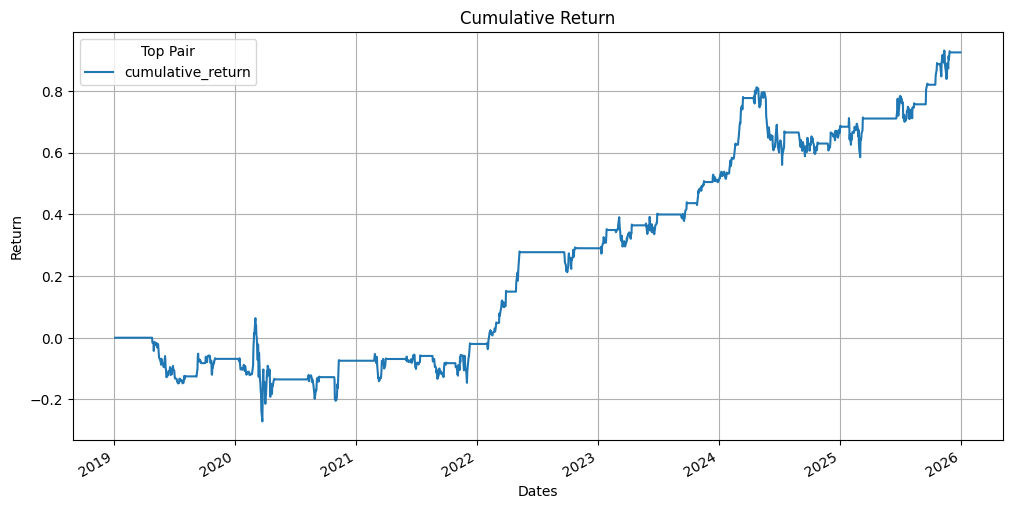

In [12]:
cumulative_returns = compute_cumulative_returns(strategy_returns)
cumulative_return_file_path = FIGURES_DIR / "v1_cumulative_return.png"
cumulative_returns.plot(figsize=(12,6))
plt.xlabel("Dates")
plt.ylabel("Return")
plt.title("Cumulative Return")
plt.legend(title="Top Pair")
plt.grid(True)
plt.savefig(cumulative_return_file_path)
plt.show()

The cumulative return shows a lot of flat or step-like periods which is expected in this threshold based pairs-trading strategy.

#### 5.2 Drawdown Curve

Plot the drawdown path of the V1 strategy.

The drawdown curve shows the decline from the previous cumulative return peak at each point in time.

This plot is important because the V1 result has meaningful return potential but also substantial downside risk. The drawdown curve helps evaluate when the largest losses occurred and how long recovery periods lasted.

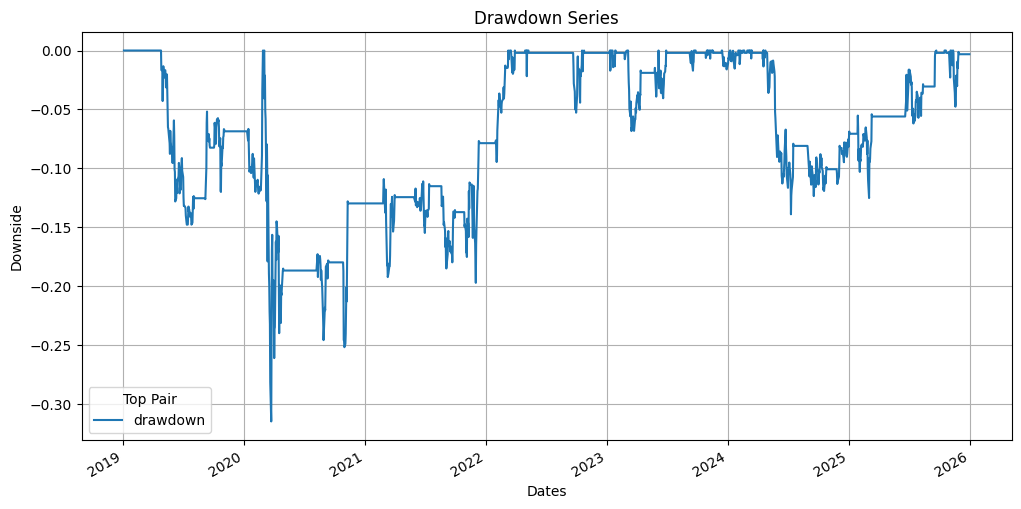

In [13]:
drawdown = compute_drawdown(strategy_returns)
drawdown_file_path = FIGURES_DIR / "v1_drawdown_series.png"
drawdown.plot(figsize=(12,6))
plt.xlabel("Dates")
plt.ylabel("Downside")
plt.title("Drawdown Series")
plt.legend(title="Top Pair")
plt.grid(True)
plt.savefig(drawdown_file_path)
plt.show()

The max drawdown ≈ -35%. The periods of higher downside risk are 2021/2022 and early 2025.The V1 strategy generated strong cumulative performance, but returns were uneven and exposed to substantial drawdowns. The result is promising as an in-sample research backtest, but not yet robust enough to treat as deployable without out-of-sample validation, cost sensitivity, and expanded universe testing.

## 6. Result Summary

The V1 backtest was run on the selected `META_CRM` pair using the configured z-score entry/exit rules, fixed upstream hedge ratio, lagged positions, and transaction-cost adjustment.

The strategy generated a final cumulative return of approximately `269.8%` over the sample period, with an annualized return of approximately `30.0%` and annualized volatility of approximately `33.2%`. The resulting Sharpe ratio was approximately `0.81`.

The strategy was active, with 38 position changes and total turnover of `39.0`. Total modeled transaction costs were approximately `7.8%` over the backtest period.

The maximum drawdown was approximately `-35.4%`, indicating that the strategy experienced substantial downside risk despite positive cumulative performance. The hit rate was approximately `18.9%`, suggesting that returns were concentrated in fewer winning periods rather than frequent small wins.

The Newey-West adjusted t-statistic for average strategy returns was approximately `2.34`, with a p-value of approximately `0.019`. This suggests that the average return was statistically significant under the V1 in-sample setup after adjusting for possible autocorrelation and heteroskedasticity.

Overall, the V1 result is promising as a research backtest, but not sufficient as a deployable strategy conclusion. The performance is economically interesting and statistically significant in-sample, but the high drawdown, low hit rate, small universe, static pair selection, and lack of out-of-sample validation mean the result requires further robustness testing in V2.


## 7. Limitations and V2 Roadmap

This V1 backtest has several important limitations:

- The result is in-sample only; no out-of-sample testing has been performed yet.
- The universe is limited to a small static set of 10 technology stocks, so selection bias may be present.
- Pair selection is static and does not use walk-forward re-selection.
- Hedge ratios are estimated upstream and held fixed during the V1 backtest.
- Portfolio construction and allocation across multiple pairs are not yet implemented.
- Transaction costs are modeled in a simplified form at the spread/backtest level.
- Slippage and market impact are not modeled.
- The JSON configuration file is not yet schema-validated or integrity-checked.
- Data loading is a one-time process and is not yet automated or scheduled.
- Automated test coverage is limited because a dedicated testing module has not yet been built.

### Planned V2 Improvements

- Expanded universe construction.
- Walk-forward pair selection.
- Out-of-sample validation.
- Transaction cost sensitivity and a more complete cost model.
- Portfolio-level aggregation across selected pairs.
- Config and artifact validation.
- Expanded pytest coverage.
- Structured logging and automated data pipeline improvements.